<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; Αναλυτικά Επιτυχίας Πελατών</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">Ανάλυση Βασικών Αιτιών Αποχώρησης Πελατών</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">Διάγραμμα αιτίου-αποτελέσματος PROC FISHBONE για μια ανασκόπηση διατήρησης πελατών B2B SaaS μεσαίας αγοράς</div>
</div>

## Περίληψη

Αυτή η ανάλυση οργανώνει τους βασικούς παράγοντες της αυξημένης αποχώρησης πελατών SaaS σε ένα δομημένο διάγραμμα αιτίου-αποτελέσματος (Ισικάβα). Το τμήμα B2B μεσαίας αγοράς αποχωρεί με ρυθμό περίπου 18% ετησίως έναντι στόχου 8%. Είκοσι ευρήματα βασικών αιτιών — αντλημένα από έρευνες αποχώρησης, συνεντεύξεις επιτυχίας πελατών και απόδοση κοορτής — ομαδοποιούνται σε έξι κατηγορίες αιτιών και αποδίδονται με την `PROC FISHBONE` ως διάγραμμα 27 κόμβων (ένα αποτέλεσμα, έξι κύριοι κλάδοι κατηγορίας, είκοσι υποαιτίες).

Η συνοδευτική ανάλυση `PROC MEANS` δείχνει πού συγκεντρώνεται η αποδιδόμενη αποχώρηση. Το **Προϊόν** συγκεντρώνει τα περισσότερα ευρήματα (5 αιτίες, 48,1 συνολικούς πόντους επίπτωσης), ακολουθούμενο από την **Τιμολόγηση** (4 αιτίες, 42,3) και την **Υποστήριξη** (4 αιτίες, 40,2). Μετρούμενο ως μέση επίπτωση *ανά αιτία*, ο **Ανταγωνισμός** είναι η πιο σοβαρή κατηγορία (μέσος όρος 11,8), και το εύρημα με τη μεγαλύτερη μεμονωμένη επίπτωση συνολικά είναι η αύξηση τιμής ανανέωσης της **Τιμολόγησης** χωρίς προηγούμενη προειδοποίηση (14,2). Η προβολή Pareto της `PROC SGPLOT` κατατάσσει κάθε μεμονωμένη αιτία ώστε η ηγεσία να βλέπει σε ποιους κλάδους να δράσει πρώτα. Το παραδοτέο τροφοδοτεί την τριμηνιαία ανασκόπηση διατήρησης της ομάδας Επιτυχίας Πελατών.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.CHURN_RCA | Ευρήματα βασικών αιτιών αποχώρησης πελατών, ενοποιημένα από ανάλυση ερευνών αποχώρησης και την αναδρομική ανασκόπηση της ομάδας CS· κάθε γραμμή είναι μία αιτία με την κατηγορία της, τα υποστηρικτικά στοιχεία, και το εκτιμώμενο μερίδιο επίπτωσης στην αποχώρηση | 20 |

---

In [1]:
/* --------------------------------------------------------
   Ευρήματα βασικών αιτιών αποχώρησης πελατών (RCA)
   Πλατφόρμα SaaS, τμήμα B2B μεσαίας αγοράς.
   Κάθε γραμμή: κατηγορία αιτίας, η συγκεκριμένη αιτία, μια
   υποστηρικτική σημείωση υποαιτίας/στοιχείων, και το
   εκτιμώμενο μερίδιο αποχώρησης που της αποδίδεται (από
   έρευνες αποχώρησης και απόδοση κοορτής).
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.churn_rca;
    INFILE DATALINES dlm='|' dsd truncover;
    ΕΙΣΟΔΟΣ category :$30. cause :$160. subcause :$160. churn_impact_pct;
    DATALINES;
Προϊόν|Κενά βασικών λειτουργιών έναντι ανταγωνιστών επιχειρησιακού επιπέδου|Όρια μαζικής εξαγωγής και ρυθμού API αναφέρθηκαν στο 34% των ερευνών αποχώρησης|12.4
Προϊόν|Περιορισμένες δυνατότητες αναφορών|Δεν υπάρχει δημιουργός προσαρμοσμένου πίνακα ελέγχου στο βασικό πακέτο|9.8
Προϊόν|Η εφαρμογή κινητού υστερεί σε σχέση με τη λειτουργικότητα ιστού|3 βασικές ροές εργασίας δεν μπορούν να ολοκληρωθούν από χρήστες μόνο κινητού|8.2
Προϊόν|Συχνές αλλαγές διεπαφής χρήστη χωρίς προειδοποίηση|Οι προχωρημένοι χρήστες διαταράσσονται από τριμηνιαίους επανασχεδιασμούς|7.6
Προϊόν|Κενά στην αγορά ενσωματώσεων|Απουσία εγγενών συνδέσεων με Salesforce και HubSpot|10.1
Τιμολόγηση|Αύξηση τιμής ανανέωσης χωρίς προηγούμενη προειδοποίηση|Αύξηση 18% στο MRR με προειδοποίηση 30 ημερών|14.2
Τιμολόγηση|Το μοντέλο χρέωσης ανά χρήστη τιμωρεί την ανάπτυξη ομάδας|Το κόστος διπλασιάζεται όταν η ομάδα αυξάνεται από 10 σε 20|11.3
Τιμολόγηση|Η αρχική έκπτωση δεν ανανεώνεται|Σοκ τιμής στην πρώτη ανανέωση|9.7
Τιμολόγηση|Δεν υπάρχει κίνητρο πολυετούς σύμβασης|Η ετήσια τιμολόγηση είναι ίδια με τη μηνιαία|7.1
Υποστήριξη|Ο χρόνος πρώτης απόκρισης υπερβαίνει τις 24 ώρες|Το πρότυπο του πακέτου είναι 4 ώρες|10.8
Υποστήριξη|Κενό ποιότητας υποστήριξης το σαββατοκύριακο|Η υπεράκτια κάλυψη δεν έχει επαρκή γνώση προϊόντος|9.3
Υποστήριξη|Δεν υπάρχει αποκλειστικός CSM κάτω από το πακέτο Enterprise|Οι λογαριασμοί μεσαίας αγοράς δεν έχουν ονομαστική επαφή|11.5
Υποστήριξη|Η διαδρομή κλιμάκωσης δεν είναι σαφής στους πελάτες|Το 38% των λογαριασμών που αποχώρησαν ανέφεραν σύγχυση σχετικά με την κλιμάκωση|8.6
Ένταξη|Ο χρόνος μέχρι την αξία υπερβαίνει τις 90 ημέρες|Η πολυπλοκότητα υλοποίησης δεν γνωστοποιείται πριν την πώληση|12.9
Ένταξη|Η τεκμηρίωση αυτοεξυπηρέτησης είναι ξεπερασμένη|Τελευταία ενημέρωση πριν από 11 μήνες|8.1
Ένταξη|Δεν υπάρχουν καθοδηγούμενες ξεναγήσεις εντός εφαρμογής για νέες λειτουργίες|Η υιοθέτηση λειτουργιών είναι κάτω από 30% στους 6 μήνες|9.4
Ανταγωνισμός|Ανταγωνιστής με τιμή χαμηλότερη κατά 30%|Τρεις μεγάλοι λογαριασμοί ανέφεραν συγκεκριμένο ανταγωνιστή|13.1
Ανταγωνισμός|Ο ανταγωνιστής προσφέρει τιμολόγηση απεριόριστων χρηστών|Εξαλείφει την ποινή ανά χρήστη για αναπτυσσόμενες ομάδες|10.6
Σχέση|Μη διαχειρίσιμη εναλλαγή στελέχους-υποστηρικτή|Ο υποστηρικτής αποχώρησε; δεν υπάρχει πρόγραμμα επανασύνδεσης|11.7
Σχέση|Η συχνότητα QBR μειώθηκε σε ετήσια|Μείωση πόρων ομάδας CS πριν από 18 μήνες|9.2
;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Βάση αναφοράς: συγκέντρωση επίπτωσης αποχώρησης ανά
   κατηγορία RCA. Το sum δείχνει πού συγκεντρώνεται η
   αποδιδόμενη αποχώρηση· το max επισημαίνει τη χειρότερη
   μεμονωμένη αιτία σε κάθε κατηγορία.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.churn_rca n sum mean MAX maxdec=1;
    ΚΛΑΣΗ category;
    ΜΕΤΑΒΛΗΤΗ churn_impact_pct;
    ΕΤΙΚΕΤΑ category='Κατηγορία Αιτίας' churn_impact_pct='Ποσοστό Επίπτωσης Αποχώρησης (%)';
    TITLE 'Ανάλυση Βασικών Αιτιών Αποχώρησης Πελατών: Ποσοστό Επίπτωσης ανά Κατηγορία';
ΕΚΤΕΛΕΣΗ;

                       Ανάλυση Βασικών Αιτιών Αποχώρησης Πελατών: Ποσοστό Επίπτωσης ανά Κατηγορία                       

                                                  The MEANS Procedure

            Analysis Variable : churn_impact_pct Ποσοστό Επίπτωσης Αποχώρησης (%)

        Κατηγορία Αιτίας                         N Obs            Sum           Mean        Maximum
        -------------------------------------------------------------------------------------------
        Ένταξη                                       3           30.4           10.1           12.9
        Ανταγωνισμός                                 2           23.7           11.8           13.1
        Προϊόν                                       5           48.1            9.6           12.4
        Σχέση                                        2           20.9           10.4           11.7
        Τιμολόγηση                                   4           42.3           10.6           14.2
        Υποστήριξη      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                       Ανάλυση Βασικών Αιτιών Αποχώρησης Πελατών: Ποσοστό Επίπτωσης ανά Κατηγορία                       




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


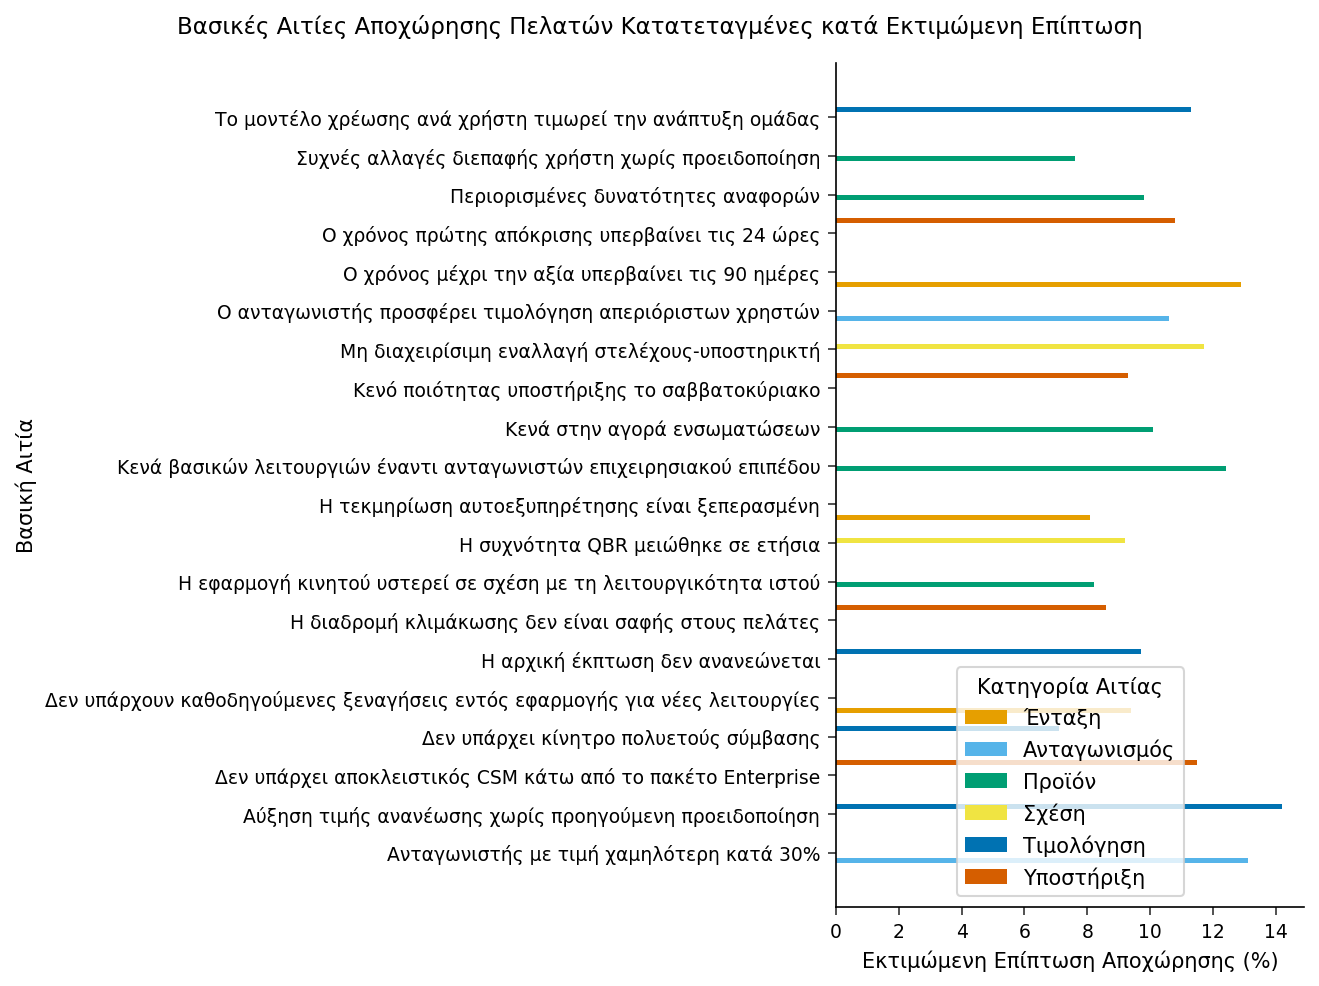

In [3]:
/* --------------------------------------------------------
   Προβολή Pareto: μεμονωμένες βασικές αιτίες κατατεταγμένες
   κατά εκτιμώμενη επίπτωση αποχώρησης, χρωματισμένες ανά
   κατηγορία. Αυτό συμπληρώνει το fishbone ποσοτικοποιώντας
   ποιοι κλάδοι έχουν τη μεγαλύτερη σημασία.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.churn_rca;
    ΚΑΤΑ DESCENDING churn_impact_pct;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    XAXIS label="Εκτιμώμενη Επίπτωση Αποχώρησης (%)";
    YAXIS label="Βασική Αιτία" discreteorder=data;
    keylegend / TITLE='Κατηγορία Αιτίας' position=bottom;
    TITLE 'Βασικές Αιτίες Αποχώρησης Πελατών Κατατεταγμένες κατά Εκτιμώμενη Επίπτωση';
ΕΚΤΕΛΕΣΗ;

---

### Διάγραμμα αιτίου-αποτελέσματος (Ισικάβα)

Η `PROC FISHBONE` κατασκευάζει το διάγραμμα απευθείας από το `WORK.CHURN_RCA`: κάθε διακριτή `category` γίνεται ένας κύριος κλάδος από την κεντρική σπονδυλική στήλη, και τα μεμονωμένα ευρήματα `cause` κρέμονται από τον κλάδο της κατηγορίας τους ως υποαιτίες. Η διαδικασία τυπώνει την πλήρη δομή αιτίου-αποτελέσματος παρακάτω — το αποτέλεσμα στην κεφαλή, τους έξι κλάδους κατηγορίας, και κάθε υποαιτία ομαδοποιημένη κάτω από τον κλάδο της — και γράφει το αντίστοιχο γραφικό fishbone στον δίσκο. Το κατατεταγμένο διάγραμμα Pareto παραπάνω είναι η συνοδευτική προβολή που ποσοτικοποιεί ποιοι από αυτούς τους κλάδους φέρουν τη μεγαλύτερη αποδιδόμενη αποχώρηση.

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE: διάγραμμα αιτίου-αποτελέσματος αποχώρησης
   πελατών. Το διάγραμμα οδηγείται απευθείας από το
   WORK.CHURN_RCA, ώστε οι έξι κατηγορίες αιτιών και οι
   αιτίες τους να είναι ακριβώς τα ευρήματα που αναλύθηκαν
   παραπάνω. Το CATEGORY σχηματίζει τους κύριους κλάδους·
   το CAUSE κρέμεται ως υποαιτίες από κάθε κλάδο.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ fishbone ΔΕΔΟΜΕΝΑ=work.churn_rca;
    cause category / subcause=cause;
    effect 'Αυξημένη Αποχώρηση Πελατών (18% ετησίως έναντι στόχου 8%)';
    TITLE 'Ανάλυση Βασικών Αιτιών Αποχώρησης Πελατών - Τμήμα Μεσαίας Αγοράς';
    footnote 'Πηγές: έρευνες αποχώρησης, συνεντεύξεις ομάδας CS, απόδοση κοορτής';
ΕΚΤΕΛΕΣΗ;

                       Ανάλυση Βασικών Αιτιών Αποχώρησης Πελατών: Ποσοστό Επίπτωσης ανά Κατηγορία                       


                    Ανάλυση Βασικών Αιτιών Αποχώρησης Πελατών - Τμήμα Μεσαίας Αγοράς
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] Αυξημένη Αποχώρηση Πελατών (18% ετησίως έναντι στόχου 8%)
    [CAUSE] Τιμολόγηση (top)
      [SUB] Αύξηση τιμής ανανέωσης χωρίς προηγούμενη προειδοποίηση
      [SUB] Το μοντέλο χρέωσης ανά χρήστη τιμωρεί την ανάπτυξη ομάδας
      [SUB] Η αρχική έκπτωση δεν ανανεώνεται
      [SUB] Δεν υπάρχει κίνητρο πολυετούς σύμβασης
    [CAUSE] Ανταγωνισμός (top)
      [SUB] Ανταγωνιστής με τιμή χαμηλότερη κατά 30%
      [SUB] Ο ανταγωνιστής προσφέρει τιμολόγηση απεριόριστων χρηστών
    [CAUSE] Ένταξη (top)
      [SUB] Ο χρόνος μέχρι την αξία υπερβαίνει τις 90 ημέρες
      [SUB] Δεν υπάρχουν καθοδηγούμενες ξεναγήσεις εντός εφαρμογής για νέες λειτουργίες
      [SUB] Η τεκμηρίωση αυτοεξυπηρέτησης είναι ξεπερασμένη
  


NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### Ερμηνεία

Η δομή αιτίου-αποτελέσματος και τα στοιχεία της `PROC MEANS` ανά κατηγορία κατευθύνουν την ηγεσία σε έναν μικρό αριθμό ενεργειών υψηλής μόχλευσης. Τα δύο ευρήματα μεμονωμένης αιτίας με τη μεγαλύτερη επίπτωση — η αύξηση τιμής ανανέωσης της **Τιμολόγησης** χωρίς προειδοποίηση (14,2) και το εύρημα του **Ανταγωνισμού** ότι ένας αντίπαλος πουλά ισοδύναμη δυνατότητα με τιμή χαμηλότερη κατά 30% (13,1) — είναι και τα δύο εμπορικά και όχι ζητήματα προϊόντος, υποδηλώνοντας ότι η διαφάνεια τιμολόγησης και η ανταγωνιστική τοποθέτηση είναι οι πιο πιεστικοί βραχυπρόθεσμοι μοχλοί. Ο χρόνος μέχρι την αξία της **Ένταξης** που υπερβαίνει τις 90 ημέρες (12,9) είναι το μεγαλύτερο εύρημα στην πλευρά της εξυπηρέτησης και συνδέεται άμεσα με τον καθορισμό προσδοκιών πριν την πώληση.

Σε όγκο, το **Προϊόν** κυριαρχεί στο διάγραμμα (5 από τα 20 ευρήματα, 48,1 συνολικούς πόντους επίπτωσης), αλλά τα ευρήματά του είναι μεμονωμένα μικρότερα (μέσος όρος 9,6) από αυτά του **Ανταγωνισμού** (μέσος όρος 11,8) ή της **Τιμολόγησης** (μέσος όρος 10,6) — μια υπενθύμιση ότι μια μακριά λίστα κενών προϊόντος δεν είναι αυτόματα η κορυφαία προτεραιότητα. Ο κλάδος **Σχέση** (εναλλαγή στελέχους-υποστηρικτή και μειωμένη συχνότητα QBR, 20,9 συνδυασμένα) αντιπροσωπεύει αλλαγές διαδικασίας που η ομάδα CS μπορεί να υλοποιήσει εντός του τρέχοντος τριμήνου χωρίς επένδυση σε προϊόν ή τιμολόγηση, προσφέροντας τη γρηγορότερη διαδρομή προς μετρήσιμη βελτίωση διατήρησης. Η πλήρης κατατεταγμένη λίστα στο διάγραμμα Pareto επιτρέπει στην ηγετική ομάδα να ιεραρχήσει τις παρεμβάσεις βάσει εκτιμώμενης επίπτωσης αντί βάσει μεγέθους κατηγορίας.

---

In [5]:
/* --------------------------------------------------------
   Εξαγωγή ευρημάτων RCA αποχώρησης για την παρουσίαση
   στρατηγικής ανασκόπησης
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>